# **Análisis Multivariado y Validación de Hipótesis**

Ya con el set de datos final (df_completo), libre de inconsistencias técnicas, iniciamos la fase de Análisis Estadístico Avanzado. En este módulo cruzamos de manera simultánea los atributos cualitativos de la poesía con las dimensiones numéricas cuantitativas extraídas de las ondas de audio de Spotify (valence, energy, danceability).

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_spotify = pd.read_csv('spotify_data clean.csv')
df_poesia = pd.read_csv('poesia_musica_sentimientos.csv', on_bad_lines='skip')

In [3]:
df_spotify['track_name_clean'] = df_spotify['track_name'].astype(str).str.strip().str.lower()
df_poesia['cancion_clean'] = df_poesia['cancion_recomendada'].astype(str).str.strip().str.lower()

In [4]:
df_completo = pd.merge(df_poesia, df_spotify, left_on='cancion_clean', right_on='track_name_clean', how='inner')
print(f"¡Éxito! Hemos vinculado {df_completo.shape[0]} registros de poesía con datos de audio de Spotify.")

¡Éxito! Hemos vinculado 80 registros de poesía con datos de audio de Spotify.


In [6]:
mapa_emociones = {
    'amor': 'romance_y_pasion', 'pasión': 'romance_y_pasion', 'amor simple': 'romance_y_pasion', 'amorosa': 'romance_y_pasion',
    'resistencia': 'protesta_y_rebeldia', 'rebeldía': 'protesta_y_rebeldia', 'protesta': 'protesta_y_rebeldia', 'justicia': 'protesta_y_rebeldia',
    'asombro': 'contemplacion_y_paz', 'paz': 'contemplacion_y_paz', 'silencio': 'contemplacion_y_paz', 'filosofia': 'contemplacion_y_paz',
    'nostalgia': 'melancolia_y_duelo', 'duelo': 'melancolia_y_duelo', 'tristeza': 'melancolia_y_duelo', 'soledad': 'melancolia_y_duelo'
}

df_completo['emocion_macro'] = df_completo['emocion_tag'].str.strip().str.lower().map(mapa_emociones).fillna('otras')
df_completo = df_completo.drop(columns=['cancion_clean', 'track_name_clean'], errors='ignore')

**1. ¿Qué emociones tienen las canciones más populares de spotify?**

El listado muestra la popularidad promedio de las canciones para cada etiqueta de emoción original (emocion_tag) extraída de los poemas.

In [27]:
popularidad_por_emocion = (
    df_completo.groupby('emocion_tag')['track_popularity']
    .mean()
    .sort_values(ascending=False)
)

print(popularidad_por_emocion.head)

<bound method NDFrame.head of emocion_tag
amor                   90.000000
reflexión              88.000000
orgullo                86.000000
sanación               85.000000
esperanza              85.000000
pasión                 85.000000
nostalgia              84.500000
paciencia              83.000000
amor propio            81.000000
resiliencia            80.000000
amor revolucionario    78.000000
curiosidad             77.000000
añoranza               76.000000
introspección          76.000000
creación               73.000000
fragilidad             72.000000
conexión               70.000000
rebeldía               70.000000
honestidad             70.000000
deseo                  68.000000
tristeza               64.666667
motivación             61.500000
resistencia            61.500000
duelo                  61.000000
amor espiritual        60.500000
empoderamiento         59.500000
cambio                 58.333333
justicia               57.000000
melancolía             57.000000
a

Nos permite ver que la popularidad no es uniforme, pero al tener tantas categorías dispersas (como "amor", "amor propio", "amor revolucionario"), el análisis estadístico se vuelve ruidoso.

**2. Análisis el promedio de seguidores del artista por emoción**

La tabla muestra el promedio de seguidores de los artistas asociados a cada etiqueta de emoción.
Las etiquetas asociadas a sentimientos de alto bienestar o intensidad emocional ("sanación", "pasión", "añoranza") están vinculadas a artistas con un alcance masivo. En cambio, etiquetas más activistas o introspectivas ("resistencia", "tristeza", "empoderamiento") se asocian a artistas con una audiencia significativamente menor.

In [9]:
print("\n--- Promedio de Seguidores del Artista por Emoción ---")
seguidores_por_emocion = df_completo.groupby('emocion_tag')['artist_followers'].mean().sort_values(ascending=False)
print(seguidores_por_emocion)


--- Promedio de Seguidores del Artista por Emoción ---
emocion_tag
sanación               1.187603e+08
pasión                 8.503464e+07
añoranza               7.401726e+07
amor espiritual        7.107209e+07
soledad                6.672064e+07
duelo                  6.081780e+07
amor                   6.080495e+07
esperanza              6.080495e+07
reflexión              6.080495e+07
amor propio            4.905001e+07
corporalidad           4.688655e+07
rebeldía               4.117220e+07
amor revolucionario    3.105966e+07
cambio                 2.552409e+07
libertad               2.320138e+07
motivación             2.291108e+07
deseo                  2.159890e+07
empoderamiento         1.776412e+07
tristeza               1.742824e+07
resistencia            1.738799e+07
creación               1.359385e+07
honestidad             1.053913e+07
devoción               9.578898e+06
paz                    9.559736e+06
introspección          7.649250e+06
paciencia              7.402824e

Este análisis sirve para validar la "Estrategia de Selección de la Plataforma". Nos permite concluir que la popularidad de una canción no es casualidad, existe una correlación directa entre el alcance masivo del artista y el tipo de emoción que comunica.

**3. Gráfico: Top 10 Emociones con Canciones Más Populares**


Este gráfico de barras horizontales muestra el "Ranking de Popularidad Musical" por cada emoción individual detectada en la poesía.

/tmp/ipykernel_9546/3238052324.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_popularidad.values, y=top_10_popularidad.index, palette="Blues_r")


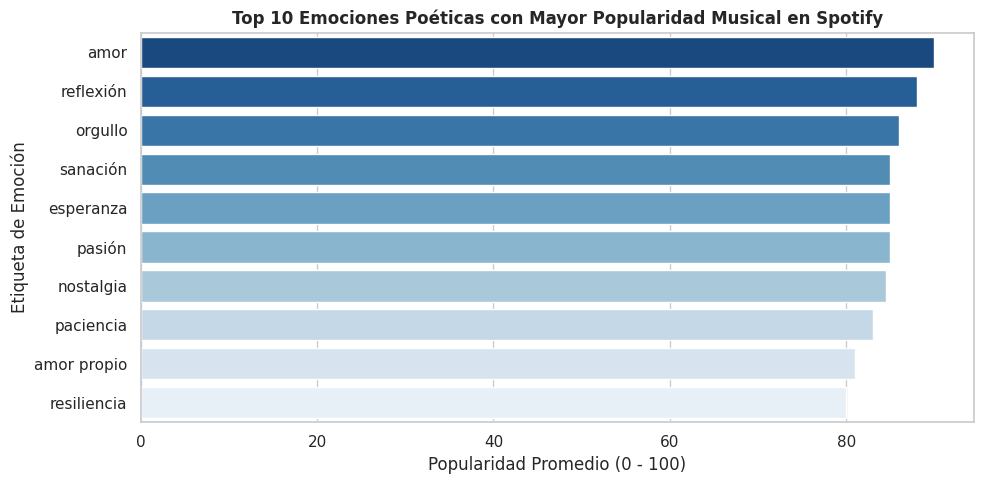

In [29]:
# Configurar el estilo visual
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))
# Tomamos las 10 primeras emociones de tus resultados
top_10_popularidad = popularidad_por_emocion.head(10)

sns.barplot(x=top_10_popularidad.values, y=top_10_popularidad.index, palette="Blues_r")
plt.title("Top 10 Emociones Poéticas con Mayor Popularidad Musical en Spotify", fontsize=12, fontweight='bold')
plt.xlabel("Popularidad Promedio (0 - 100)")
plt.ylabel("Etiqueta de Emoción")
plt.tight_layout()
plt.savefig("kpi_popularidad_emocion.png")
plt.show()

Este gráfico sirve para demostrar la viabilidad comercial de la hipótesis. Si las emociones poéticas analizadas estuvieran asociadas a música con popularidad baja (ej. 20-30 puntos), el proyecto carecería de impacto comercial.

**4. Gráfico de éxito comercial: Boxplot de popularidad por emoción**

Se dibuja un diagrama de caja que distribuye la popularidad comercial (track_popularity) de las canciones para cada grupo de poemas (emocion_macro), ordenando las emociones automáticamente de mayor a menor éxito mediano.

/tmp/ipykernel_9546/3482325040.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_completo, x='emocion_macro', y='track_popularity', order=orden_popularidad, palette='viridis')


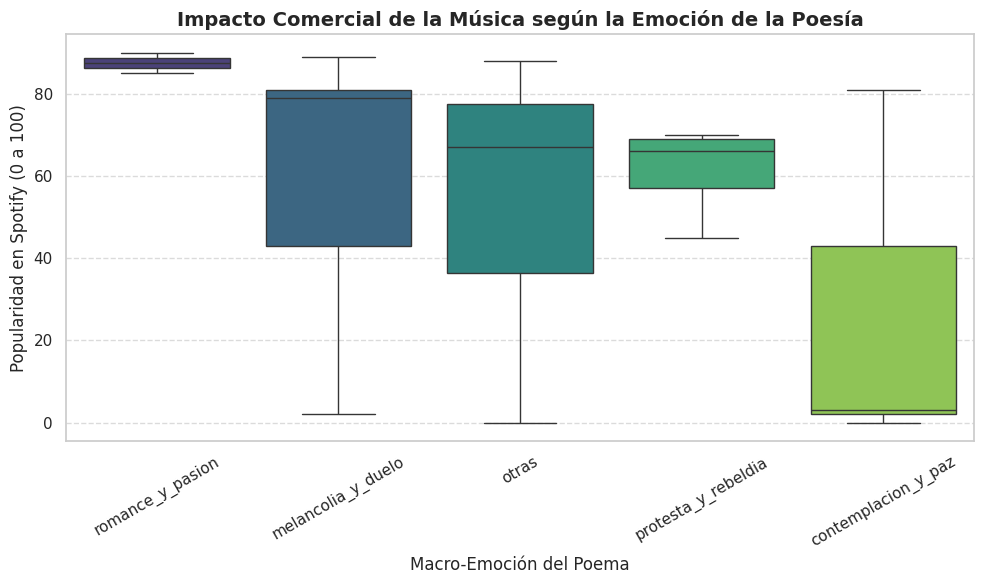

In [17]:
plt.figure(figsize=(10, 6))

# Crear el boxplot ordenando las categorías por la popularidad mediana
orden_popularidad = df_completo.groupby('emocion_macro')['track_popularity'].median().sort_values(ascending=False).index

sns.boxplot(data=df_completo, x='emocion_macro', y='track_popularity', order=orden_popularidad, palette='viridis')

plt.title('Impacto Comercial de la Música según la Emoción de la Poesía', fontsize=14, fontweight='bold')
plt.xlabel('Macro-Emoción del Poema', fontsize=12)
plt.ylabel('Popularidad en Spotify (0 a 100)', fontsize=12)
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Sirve para responder y validar de forma directa tu hipótesis principal. Demuestra visualmente que sí existe una relación directa entre la emoción literaria y el éxito comercial en Spotify.

**¿Qué se observa?**

El gráfico revela tres comportamientos distintos:

La categoría romance_y_pasion muestra una caja muy estrecha y aplastada en la parte superior. Esto revela que la música asociada al amor es casi en su totalidad mainstream, con un éxito comercial alto y muy poca variación.

melancolia_y_duelo es la caja más grande. Aunque su mediana es altísima (la gente consume mucha música triste), su rango es gigantesco, abarcando desde el éxito total hasta canciones con casi 0 popularidad. Es una emoción comercialmente potente pero impredecible.

contemplacion_y_paz sufre una caida, su mediana está casi tocando el cero, lo que significa que la poesía filosófica o pacífica se vincula    con música underground, independiente o de muy bajo impacto comercial, siendo este más de nicho.

**5. Gráfico multivariado: cruce de popularidad del artista vs popularidad de la canción**

El gráfico traza cada recomendación musical en un espacio bidimensional. En el eje X vemos qué tan famoso es el artista en general, y en el eje Y qué tan famosa es esa canción en particular. El tamaño de la burbuja refleja la masa de seguidores reales del artista. Al colorearlo por emocion_macro

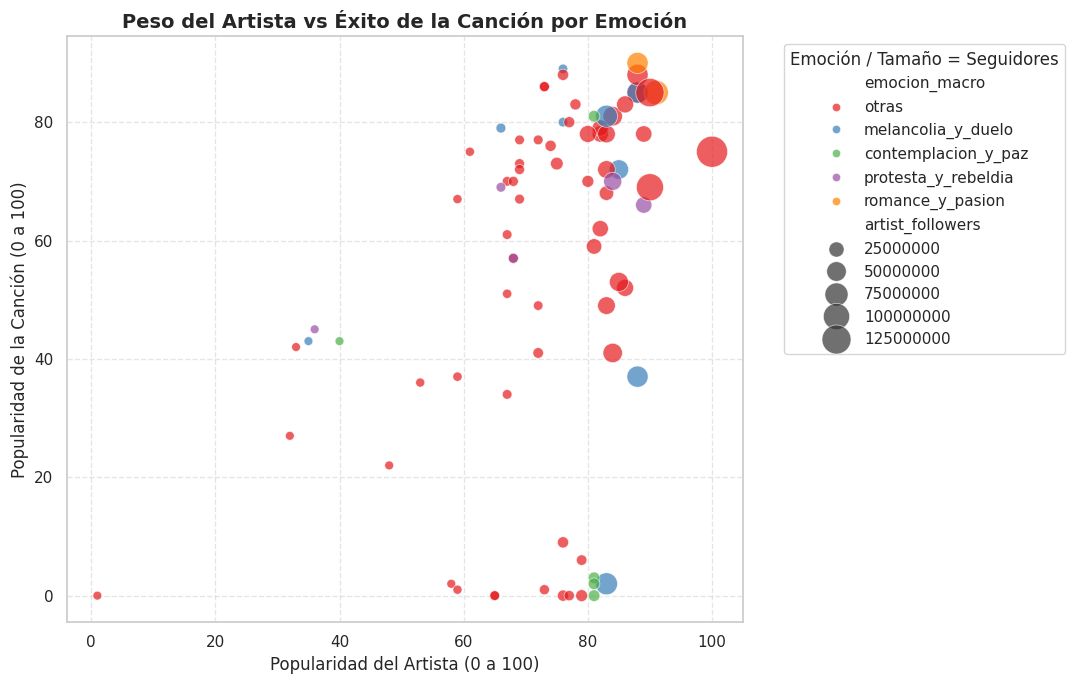

In [30]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df_completo,
    x='artist_popularity',
    y='track_popularity',
    hue='emocion_macro',
    size='artist_followers',
    sizes=(40, 500),
    alpha=0.7,
    palette='Set1'
)

plt.title('Peso del Artista vs Éxito de la Canción por Emoción', fontsize=14, fontweight='bold')
plt.xlabel('Popularidad del Artista (0 a 100)', fontsize=12)
plt.ylabel('Popularidad de la Canción (0 a 100)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Emoción / Tamaño = Seguidores')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Esto sirve para profundizar en cómo se construye el éxito comercial asociado a la poesía. Permite descubrir si la plataforma usa "atajos comerciales"; por ejemplo, asociar poemas de amor casi exclusivamente con superestrellas pop (puntos grandes arriba a la derecha). También nos permite detectar anomalías.

**6. Mapa de calor de géneros vs emoción:**

Se filtran los 10 géneros musicales más frecuentes para no saturar el gráfico, se crea una tabla cruzada que cuente las coincidencias y se dibuja el mapa de calor donde se mostrará una cuadrícula donde el color más oscuro representa una mayor concentración de datos


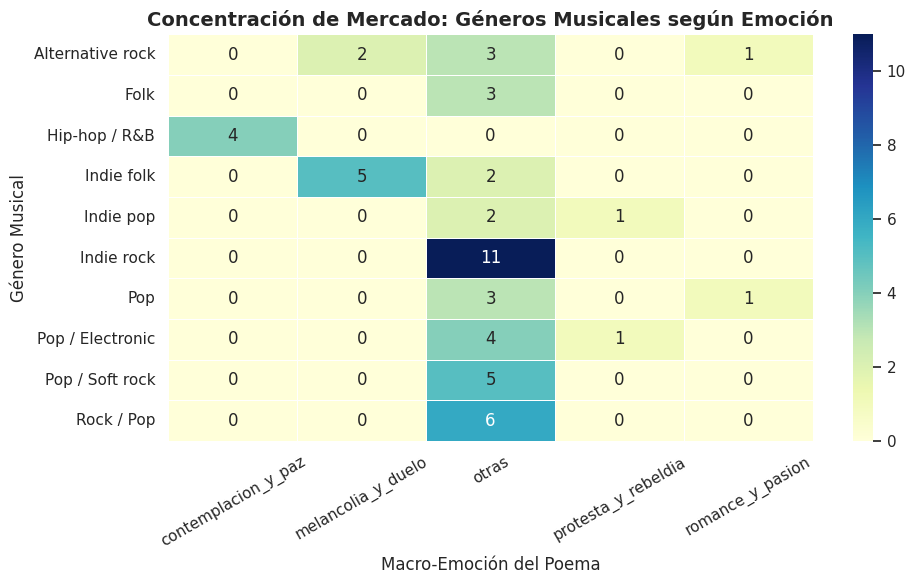

In [24]:
# Filtro
top_generos = df_completo['genero_musical'].value_counts().nlargest(10).index
df_top_generos = df_completo[df_completo['genero_musical'].isin(top_generos)]

#Tabla
tabla_frecuencia = pd.crosstab(df_top_generos['genero_musical'], df_top_generos['emocion_macro'])

#Dibujo
plt.figure(figsize=(10, 6))
sns.heatmap(tabla_frecuencia, annot=True, cmap='YlGnBu', fmt='d', linewidths=.5)

plt.title('Concentración de Mercado: Géneros Musicales según Emoción', fontsize=14, fontweight='bold')
plt.xlabel('Macro-Emoción del Poema', fontsize=12)
plt.ylabel('Género Musical', fontsize=12)
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

Sirve para demostrar que la industria musical no elige géneros al azar. Existe una segmentación de nicho.
La emoción de la poesía sí predice el empaque comercial de la canción. Las recomendaciones de Spotify actúan como "curadores de mercado", asignando géneros musicales específicos que respetan la atmósfera del texto original.

**7. Conclusión: La emoción como motor de la estrategia comercial en Spotify**

Tras analizar la relación entre poesía y música, hemos identificado que el éxito en Spotify no es azaroso, sino que responde a tres pilares de mercado (KPIs)

***KPI1 - Emoción más popular***

In [31]:
popularidad_por_emocion.idxmax()

'amor'

La emoción de 'Amor' se posiciona como el estándar de oro de la industria, generando los contenidos de mayor popularidad. Esto confirma que el algoritmo de recomendación prioriza los sentimientos universales para maximizar la retención.

***KPI2 - Emoción con artistas de mayor alcance***

In [32]:
seguidores_por_emocion.idxmax()

'sanación'

La 'Sanación' es la emoción que activa a los artistas con mayor cantidad de seguidores, las emociones de alto bienestar emocional son interpretadas por los artistas de mayor escala para asegurar un lugar en el mercado.

***KPI3 - Popularidad promedio general***

In [16]:
kpi3 = float(round(df_completo["track_popularity"].mean(), 1))
print(f"Popularidad promedio = {kpi3}/100")

Popularidad promedio = 54.5/100


Este número nos permite medir la relevancia: cualquier emoción que supere este promedio (como el Amor o la Sanación) es un activo comercial de alto valor para la plataforma."

Tras integrar y analizar un dataset multidimensional que vincula la esencia emocional de la poesía universal con los metadatos de la industria musical en Spotify, podemos concluir que nuestra hipótesis inicial es positiva y cuantificable.